In [ ]:
"""
OS-SELECT is called "order statistic select" because it returns the
i-th smallest element (the i-th order statistic) in the tree.

It works on a red-black tree augmented with a size field storing the
number of nodes in each subtree. This allows rank and selection
operations to run in O(log n) time instead of O(n).
"""

In [1]:
"""
Example: Find the 5th smallest element using os_select.

Tree (value(size)):
        20(7)
       /     \
   10(3)     30(3)
   /   \     /   \
 5(1) 15(1)25(1)35(1)

Sorted order: [5, 10, 15, 20, 25, 30, 35]

os_select(20, 5)

Step 1: At node 20
left.size = 3
r = left.size + 1 = 4
i = 5, r = 4 → i > r
Go right and subtract skipped nodes
Next call: os_select(30, 5 - 4) = os_select(30, 1)

Step 2: At node 30
left.size = 1
r = 1 + 1 = 2
i = 1, r = 2 → i < r
Go left
Next call: os_select(25, 1)

Step 3: At node 25
left.size = 0
r = 0 + 1 = 1
i = 1, r = 1 → match found

Return 25

Traversal path: 20 → 30 → 25
Result: 5th smallest element = 25
"""
def os_select(x, i):
    if x is None:
        return None

    left_size = x.left.size if x.left else 0
    r = left_size + 1

    if i == r:
        return x
    elif i < r:
        return os_select(x.left, i)
    else:
        return os_select(x.right, i - r)

In [2]:
"""
OS-RANK rule:
While moving from node x up to the root:
1. If x is a right child, add size(parent.left) + 1 to r.
2. If x is a left child, add nothing.
3. Move x to its parent and repeat the check independently at each level until reach
"""
def os_rank(t, x):
    r = (x.left.size if x.left else 0) + 1
    while x is not t.root:
        if x == x.p.right:
            left_size = x.p.left.size if x.p.left else 0
            r = r + left_size + 1
        x = x.p
    return r

In [3]:
"""
if instead we traverse the tree
inorder traversal → count until we reach x
O(n)

OS-RANK
OS-SELECT
O(log n)
"""

'\nif instead we traverse the tree\ninorder traversal → count until we reach x\nO(n)\n\nOS-RANK\nOS-SELECT\nO(log n)\n'

In [4]:
"""
non-recursive version
"""
def os_select(x, i):
    while x is not None:
        left_size = x.left.size if x.left else 0
        r = left_size + 1

        if i == r:
            return x
        elif i < r:
            x = x.left
        else:
            i = i - r
            x = x.right

    return None

In [7]:
"""
OS-KEY-RANK(T, k): computes the rank of key k by performing
a BST search from the root while accumulating subtree sizes.

root → child → child → ... → node

OS-RANK:   node → root
OS-KEY-RANK: root → node
"""
def os_key_rank(T, k):
    x = T.root
    r = 0

    while x is not None:
        left_size = x.left.size if x.left else 0

        if k < x.key:
            x = x.left

        elif k > x.key:
            r = r + left_size + 1
            x = x.right

        else:  # k == x.key
            return r + left_size + 1

    return None

In [10]:
"""
NOTE: r + i > n
then the i-th successor does not exist.

node x → find its rank
rank + i → find the node with that rank
"""
def os_ith_successor(T, x, i):
    r = os_rank(T, x)
    return os_select(T.root, r + i)

In [11]:
"""
if we keep track of rank instead (and have to perform insertions/rotations/deletions):
Store rank[x] = size(x.left) + 1.

Insertion:
While descending the tree, if the new key goes left of node x,
increment rank[x].

Deletion:
While descending toward the node being deleted, if the search
moves left from x, decrement rank[x].

Rotations:
Left rotation at x:
    rank[y] = rank[y] + rank[x]

Right rotation at y:
    rank[y] = rank[y] - rank[x]

Each node tracks its own rank, i.e., "position within its subtree."
During insertion/deletion, only nodes on the path to the inserted/deleted node need updates.
During rotations, only the rotated nodes’ rank fields need adjustment.

update parent nodes on the path, plus affected nodes during rotations, not the entire tree.
"""

'\nif we keep track of rank instead (and have to perform insertions/rotations/deletions):\nStore rank[x] = size(x.left) + 1.\n\nInsertion:\nWhile descending the tree, if the new key goes left of node x,\nincrement rank[x].\n\nDeletion:\nWhile descending toward the node being deleted, if the search\nmoves left from x, decrement rank[x].\n\nRotations:\nLeft rotation at x:\n    rank[y] = rank[y] + rank[x]\n\nRight rotation at y:\n    rank[y] = rank[y] - rank[x]\n\nEach node tracks its own rank, i.e., "position within its subtree."\nDuring insertion/deletion, only nodes on the path to the inserted/deleted node need updates.\nDuring rotations, only the rotated nodes’ rank fields need adjustment.\n'

In [12]:
def empty_order_statistic_tree(T):
    T.root = None

In [ ]:
"""
Count inversions in O(n log n) using order-statistic tree:
Initialize empty OST T and inversions = 0.

For each element x in array A:
r = OS-KEY-RANK(T, x)
inversions += size(T) - r
OS-INSERT(T, x)
Return inversions.

Time: O(n log n)
"""
def count_inversions(A):
    T = empty_order_statistic_tree()
    inversions = 0

    for x in A:
        if T.root is not None:
            r = os_key_rank(T, x)
            greater_count = size(T.root) - r
            inversions += greater_count
        os_insert(T, x)

    return inversions

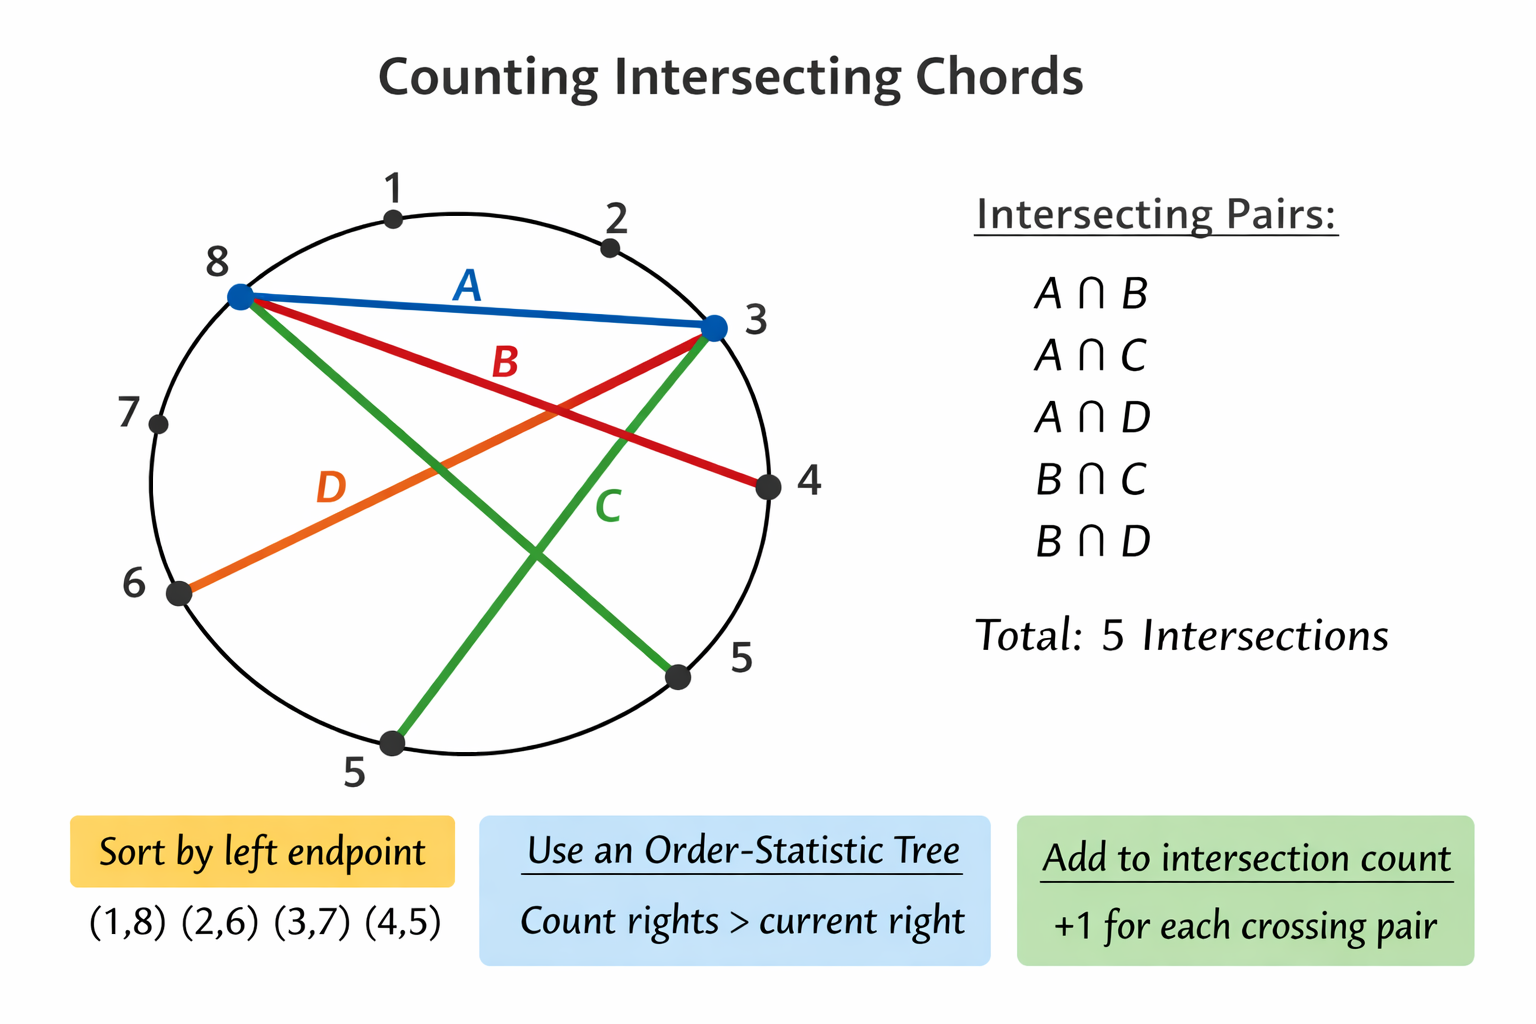

In [17]:
from IPython.display import Image, display

# Path to the image
img_path = "./mnt/data/intersections.png"

# Display the image
display(Image(filename=img_path))

In [18]:
def count_chord_intersections(chords):
    # chords = list of (start, end)
    chords = [(min(a,b), max(a,b)) for a,b in chords]
    chords.sort(key=lambda x: x[0])  # sort by left endpoint

    OST = empty_order_statistic_tree()
    intersections = 0

    for left, right in chords:
        # number of chords already inserted with right > current right
        r = os_key_rank(OST.root, right)  # rank = number of nodes <= right
        count_greater = OST.root.size - r  # nodes with right > current right
        intersections += count_greater
        OST.root = os_insert(OST.root, right)  # insert current right

    return intersections

In [ ]:
def interval_search(t, i):
    x = t.root
    
    while x is not None and not overlap(i, x.int):
        if x.left is not None and x.left.max >= i.low:
            x = x.left
        else:
            x = x.right
            
    return x